In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

(512, 512)

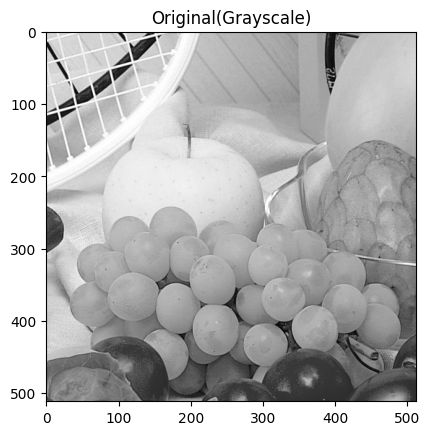

In [ ]:
img = cv2.imread('fruits.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title('Original(Grayscale)')
img.shape

# **Task - 1**

Image Negative

Text(0.5, 1.0, 'Negative')

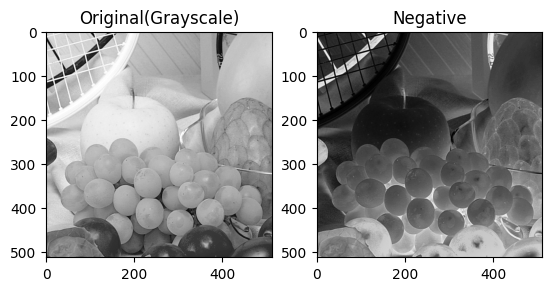

In [ ]:
L = 255
img_neg = L - img

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original(Grayscale)')

plt.subplot(1, 2, 2)
plt.imshow(img_neg, cmap='gray')
plt.title('Negative')

###Inference:
The graylevels of the image are completely flipped, The whiter the pixel the blacker it becomes in the negetive

Log Transform

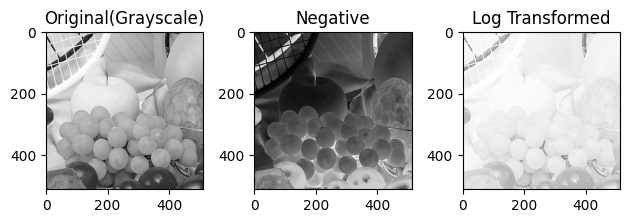

In [ ]:
img = np.array(img, dtype = np.float32)

c = 255/(np.log(1 + np.max(img)))
img_log = c * np.log(img+1)
img_log = np.array(img_log, dtype = np.uint8)
img = np.array(img, dtype = np.uint8)

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original(Grayscale)')

plt.subplot(1, 3, 2)
plt.imshow(img_neg, cmap='gray')
plt.title('Negative')

plt.subplot(1, 3, 3)
plt.imshow(img_log, cmap='gray')
plt.title('Log Transformed')

plt.tight_layout()
plt.show()

###Inference:
Log tranform maps a narrow range of intensity values in the input into a wider range of output levels.

Gamma Correction

In [ ]:
def gamma_correction(img, gamma):
  image = np.array(img, dtype = np.float32)
  gamma_corrected_image = np.power(image / 255.0, gamma) * 255
  return gamma_corrected_image.astype(np.uint8)

Text(0.5, 1.0, 'Gamma = 2.5')

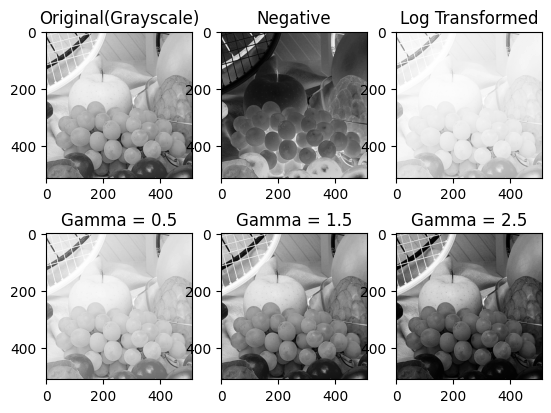

In [ ]:
img_gamma_1 = gamma_correction(img, 0.5)
img_gamma_2 = gamma_correction(img, 1.5)
img_gamma_3 = gamma_correction(img, 2.5)

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original(Grayscale)')

plt.subplot(2, 3, 2)
plt.imshow(img_neg, cmap='gray')
plt.title('Negative')

plt.subplot(2, 3, 3)
plt.imshow(img_log, cmap='gray')
plt.title('Log Transformed')

plt.subplot(2, 3, 4)
plt.imshow(img_gamma_1, cmap='gray')
plt.title('Gamma = 0.5')

plt.subplot(2, 3, 5)
plt.imshow(img_gamma_2, cmap='gray')
plt.title('Gamma = 1.5')

plt.subplot(2, 3, 6)
plt.imshow(img_gamma_3, cmap='gray')
plt.title('Gamma = 2.5')

###Inference:
Gamma correction can make images look more natural by helping to differentiate between dark tones and revealing subtle details in both dark and bright areas.


# **Task - 2**

Contrast Stretching

In [ ]:
min_val = np.min(img)
max_val = np.max(img)
img_contrast = (img - min_val) / (max_val - min_val) * 255

img_contrast = np.array(img_contrast, dtype = np.uint8)

min_val, max_val

(0, 255)

Text(0.5, 1.0, 'Contrast Enhanced')

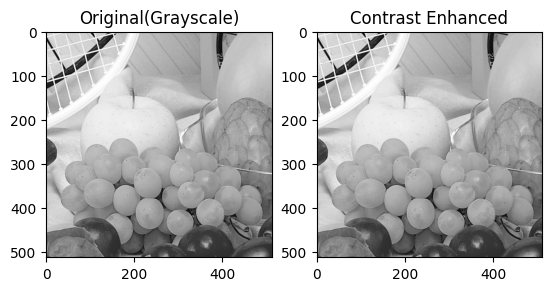

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original(Grayscale)')

plt.subplot(1, 2, 2)
plt.imshow(img_contrast, cmap='gray')
plt.title('Contrast Enhanced')

###Inference:
This image already has all values from 0-255, SO the stretching isn't that helpful

Histogram

In [ ]:
hist_0 = cv2.calcHist([img], [0], None, [256], [0, 256])
hist_1 = cv2.calcHist([img_contrast], [0], None, [256], [0, 256])

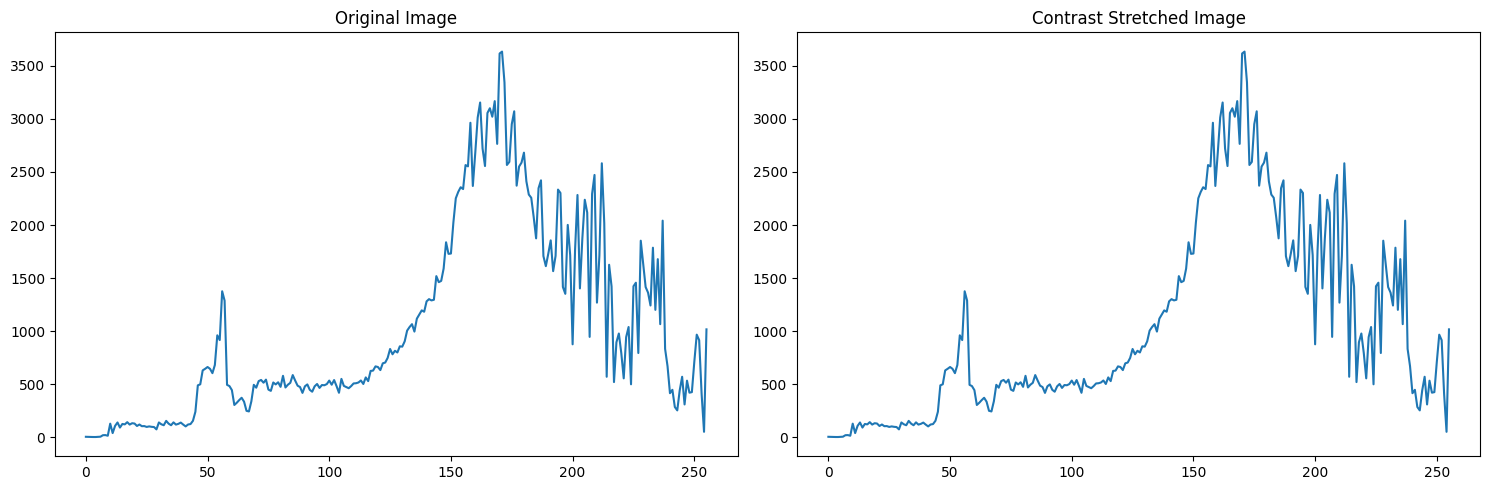

In [ ]:
plt.figure(figsize = [15, 5])
plt.subplot(1, 2, 1)
plt.plot(hist_0)
plt.title('Original Image')
plt.xlabel = 'Pixel Value'
plt.ylabel = 'Frequency'

plt.subplot(1, 2, 2)
plt.plot(hist_1)
plt.title('Contrast Stretched Image')
plt.xlabel = 'Pixel Value'
plt.ylabel = 'Frequency'

plt.tight_layout()
plt.show()

###Inference:
This gives a great visualization of the distribution of the gray levels

# **Task - 3**

Contrast Enhancement using Histogram Enhancement

Text(0.5, 1.0, 'Histogram Equalized')

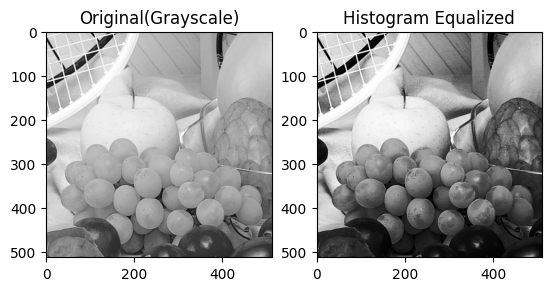

In [ ]:
img_equ = cv2.equalizeHist(img)

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original(Grayscale)')

plt.subplot(1, 2, 2)
plt.imshow(img_equ, cmap='gray')
plt.title('Histogram Equalized')

In [ ]:
hist_2 = cv2.calcHist([img_equ], [0], None, [256], [0, 256])

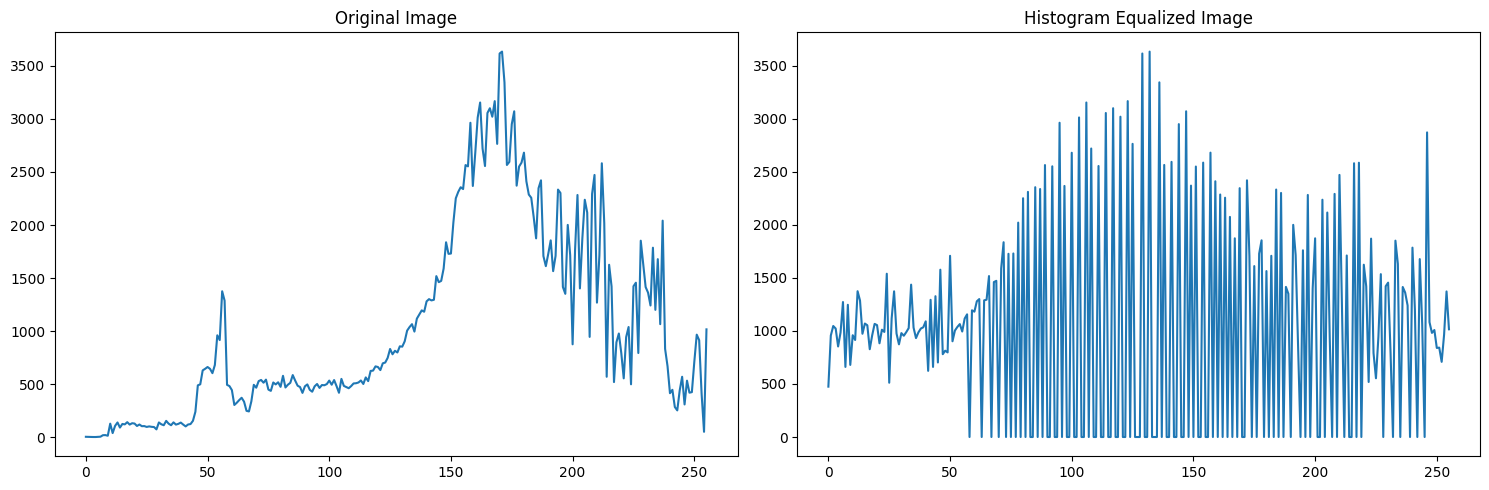

In [ ]:
plt.figure(figsize = [15, 5])
plt.subplot(1, 2, 1)
plt.plot(hist_0)
plt.title('Original Image')
plt.xlabel = 'Pixel Value'
plt.ylabel = 'Frequency'

plt.subplot(1, 2, 2)
plt.plot(hist_2)
plt.title('Histogram Equalized Image')
plt.xlabel = 'Pixel Value'
plt.ylabel = 'Frequency'

plt.tight_layout()
plt.show()

###Inference:
Using Histogram equalization aids in proper contrast stretching where darker parts become darker and brighter parts become brighter

# **Task - 4**

Histogram Equalization on Noisy Image

In [ ]:
img_noisy = cv2.imread('noisy.jpg', cv2.IMREAD_GRAYSCALE)

Text(0.5, 1.0, 'Noisy Histogram Equalized')

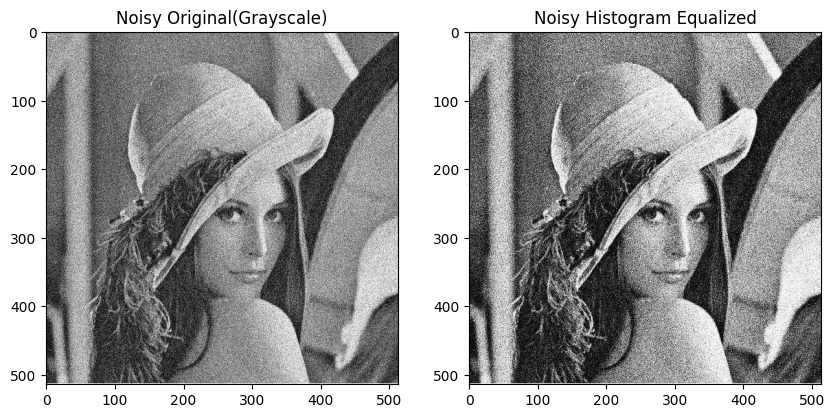

In [ ]:
noisy_equ = cv2.equalizeHist(img_noisy)

plt.figure(figsize = [10, 5])

plt.subplot(1, 2, 1)
plt.imshow(img_noisy, cmap='gray')
plt.title('Noisy Original(Grayscale)')

plt.subplot(1, 2, 2)
plt.imshow(noisy_equ, cmap='gray')
plt.title('Noisy Histogram Equalized')

In [ ]:
hist_3 = cv2.calcHist([img_noisy], [0], None, [256], [0, 256])
hist_4 = cv2.calcHist([noisy_equ], [0], None, [256], [0, 256])

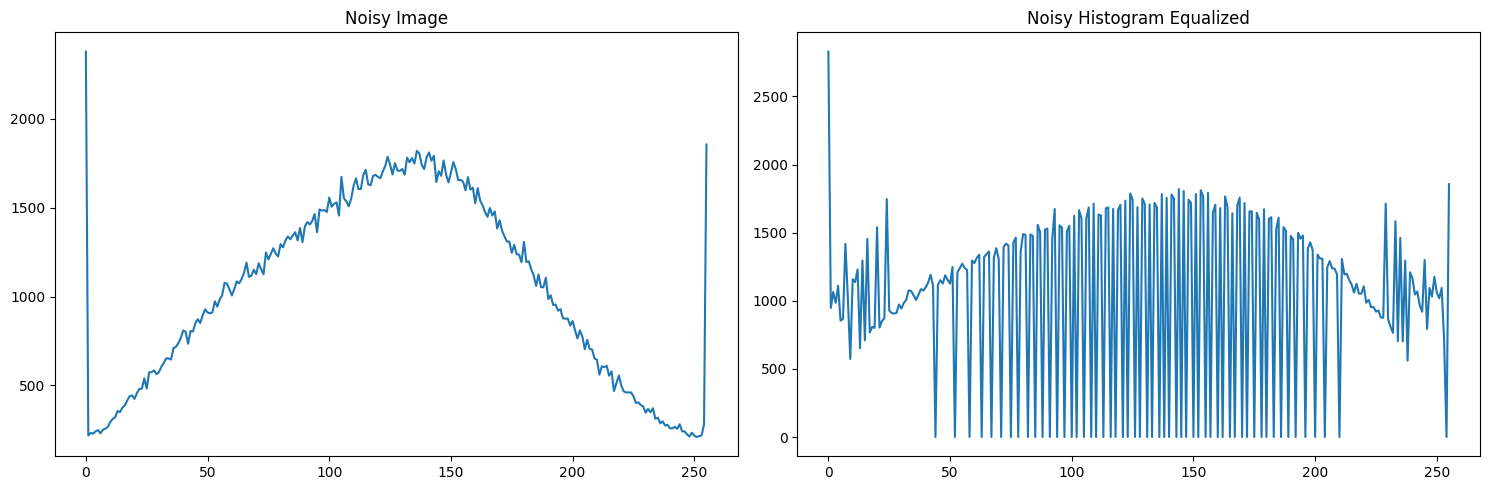

In [ ]:
plt.figure(figsize = [15, 5])
plt.subplot(1, 2, 1)
plt.plot(hist_3)
plt.title('Noisy Image')
plt.xlabel = 'Pixel Value'
plt.ylabel = 'Frequency'

plt.subplot(1, 2, 2)
plt.plot(hist_4)
plt.title('Noisy Histogram Equalized')
plt.xlabel = 'Pixel Value'
plt.ylabel = 'Frequency'

plt.tight_layout()
plt.show()

###Inference:
The overall contrast is increased despite the noise